### Assess rupture correlation between PDFs from multiple sites ###


***Bhattacharyya coefficient (B coefficient)***

We start with the first step in integrating paleoseismic data. This is to identify correlations between event-age probability distributions (PDFs) from different sites. We assess such correlation by computing the Bhattacharyya coefficient (B coefficient, equation 1) between PDF's from two different trench sites A and B. 

$B\text{ coefficient }(A,B)=\sum \sqrt{\,P_A(t_i)\,P_B(t_i)\,}$ (1)

In [4]:
!pip install seaborn

---------------------------------------------------------------------------------------------------------------------------------------------
***Loading Data***\
Here, we load the paleoearthquake catalogs from the two trench sites we aim to compare. Each dataset consists of multiple columns, including a time column and the corresponding probability distribution over the considered time range. These data represent the modeled ages of individual events, derived from OxCal chronological models.
Each event is labeled according to its respective nomenclature. for example, in <b>T1_aksay.txt</b> contains all events identified at trench site T1 along the Aksay section. Similarly, separate files are created for other trench sites, such as the Mobaer trench, with each file compiling the events documented at that specific location.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#from scipy.integrate import simps
from scipy.integrate import simpson
import pandas as pd
import seaborn as sns
import random
from pathlib import Path

#READ AND LOAD DATA

BASE_DIR = Path.cwd().resolve()

trench1 = BASE_DIR / "data" / "T1_aksay.txt"
trench2 = BASE_DIR / "data" / "mobaer.txt"

df1 = pd.read_csv(trench1, sep='\t', header=0).fillna(0)
df2 = pd.read_csv(trench2, sep='\t', header=0).fillna(0)

data1 = df1.columns.tolist()
data2 = df2.columns.tolist()

time = df1['time']
dt = 5 #time step resolution from Oxcal
#print(time)


---------------------------------------------------------------------------------------------------------------------------------------------
***Looking for Potential Event Correlations***\
Here, we construct a set of nested for-loops to compute all possible pairwise overlaps between events and quantify their degree of agreement using the B coefficient.
Before performing these calculations, we initialize empty DataFrames to store the overlap values obtained from both the B coefficient method and the Minimum Probability method.

The probabilistic overlap between events(PDFs) based on the B coefficient method:


<Axes: >

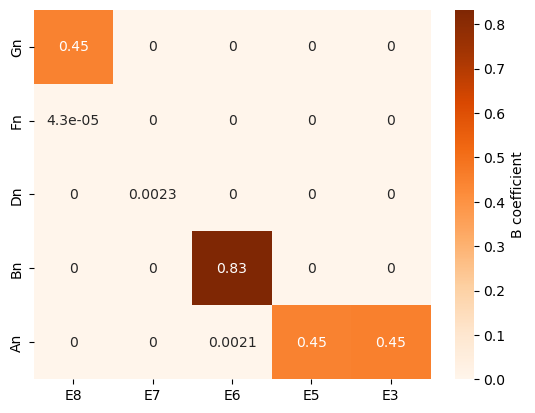

In [10]:
df = pd.DataFrame(np.zeros((len(df2.columns)-1,len(df1.columns)-1)), # stores the overlap from the B coefficient 
                  index=[x for x in data2 if x!= "time"], 
                  columns = [y for y in data1 if y != "time"])

df_x = df.copy() # stores the overlap express only in terms of time based on the B coefficient
df4 = df.copy() # stores the overlap from the minimium values between PDFs

for i in df1.columns:
    if i == 'time':
        continue
    for k in df2.columns:
        if k == 'time':
            continue
        pdf_a = df1[i].values
        pdf_b = df2[k].values
        pdf_a /= np.sum(pdf_a)
        pdf_b /= np.sum(pdf_b)
        bc = simpson(np.sqrt(pdf_a * pdf_b),
                     np.arange(0,np.size(time)), dx=dt)
        
        overlap = np.sum(np.minimum(pdf_a, pdf_b))
        df4.loc[k, i] = overlap
        df.loc[k, i] = bc
        x = np.sqrt(pdf_a * pdf_b)
        vector=[] # este vector en cada iteracion se llena de valores y al terminar una iter y comenzar la otra queda vacia
        for j in x:
            if j > 1e-3: # we set a very low probability threshold to compute the temporal overlap 
                vector.append(j)
                dx = np.size(vector)* dt - dt
                df_x.loc[k, i] = dx
print("The probabilistic overlap between events(PDFs) based on the B coefficient method:")                
sns.heatmap(df,annot=True, cmap="Oranges", cbar_kws={'label': 'B coefficient'})  
#plt.savefig('T1_annanbaa.pdf', dpi = 700,format='pdf')  

---------------------------------------------------------------------------------------------------------------------------------------------
***Temporal overlap based on the B coefficient***\
Run the lines below if you want to examine what the probabilistic overlap, as defined by the B coefficient, represents in terms of time.

In [11]:
print("The temporal overlap (in yrs) based on the B coefficient methods is:")
print(df_x)

The temporal overlap (in yrs) based on the B coefficient methods is:
       E8   E7     E6     E5     E3
Gn  895.0  0.0    0.0    0.0    0.0
Fn    0.0  0.0    0.0    0.0    0.0
Dn    0.0  0.0    0.0    0.0    0.0
Bn    0.0  0.0  535.0    0.0    0.0
An    0.0  0.0    0.0  390.0  415.0


---------------------------------------------------------------------------------------------------------------------------------------------
***Plotting B coefficient overlap between PDFs***\
If needed, it is possible to plot the Bhattacharyya overlap area between selected PDFs of particular interest. This allows visualization of where the overlap occurs in time. For example, the overlap between two PDFs may be centered around the mean of both distributions (as in the case of An and E5), or it may occur along the tail of a broader PDF relative to a narrower one (as in the case of An and E3).

These types of observations, together with geological evidence, can help determine which correlation is more strongly supported when a PDF from one trench site exhibits multiple overlaps with PDFs from another site.

area bewteen An and E5: 0.447081561972923
area bewteen An and E3: 0.45299424241878705


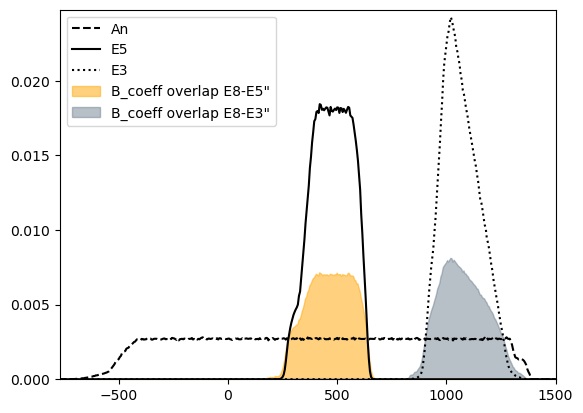

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [12]:
pdf1 = df2['An'].values #change the name of the event of interest. It has to be the same as in the txt file
pdf2 = df1['E5'].values #change the name of the event of interest. It has to be the same as in the txt file
pdf3 = df1['E3'].values #change the name of the event of interest. It has to be the same as in the txt file

pdf1 /= np.sum(pdf1)
pdf2 /= np.sum(pdf2)
pdf3 /= np.sum(pdf3)

area_1 =  np.sqrt(pdf1*pdf2)  
area_2 =  np.sqrt(pdf1*pdf3) 
print("area bewteen An and E5:",np.sum(area_1))
print("area bewteen An and E3:",np.sum(area_2))

plt.plot(time, pdf1, "k--", label='An')
plt.plot(time, pdf2,"k", label='E5')
plt.plot(time, pdf3, "k:", label='E3' )
plt.fill_between(time, 0, area_1, alpha=0.5, color='orange', label='B_coeff overlap E8-E5"')
plt.fill_between(time, 0, area_2, alpha=0.5, color='slategrey', label='B_coeff overlap E8-E3"')
plt.xlim(-770, 1500)
#plt.xlim(time[min_idx]-10, time[max_idx]+10)
plt.ylim(0, np.max(pdf3) + 0.0005)
plt.legend()
#plt.savefig('An-E5(2PTION).pdf', bbox_inches='tight')

#plt.plot(time, pdf1, "k:", label='PDF 1')
plt.show()
plt.figure()